# 📊 Analisis Klasifikasi Rimpang (Median Blur + CLAHE)

---

## 🧪 Ringkasan Eksperimen

| Atribut | Detail |
|---|---|
| **Nama Eksperimen** | P4_Median_CLAHE |
| **Tujuan** | Klasifikasi citra rimpang: Jahe, Kunyit, Lengkuas |
| **Preprocessing** | Resize 128×128 → Grayscale → Median Blur (kernel 10) → CLAHE |
| **Fitur** | GLCM (24) + Warna (6) + LBP (10) = **40 fitur** |
| **Split Data** | 80% Train (504) / 20% Test (126), Stratified |
| **Model** | KNN, SVM, Random Forest |

---

## 💡 Hipotesis Awal

> *"Citra rimpang hasil pemotretan kemungkinan mengandung noise (mis. tekstur permukaan kasar, debu, atau variasi pencahayaan kecil) yang dapat mengaburkan pola tekstur sebenarnya. Dengan menambahkan **Median Blur** sebelum **CLAHE**, noise tipe salt-and-pepper diharapkan tereduksi terlebih dahulu sehingga proses penguatan kontras adaptif oleh CLAHE bekerja pada citra yang lebih 'bersih', menghasilkan fitur GLCM dan LBP yang lebih representatif dan stabil. Akurasi diharapkan kompetitif (≥70%) pada model terbaik, dengan **gap train-test yang lebih kecil** dibanding eksperimen tanpa denoising, karena fitur yang dihasilkan diharapkan lebih general (tidak menangkap noise sebagai pola)."*

**Dasar hipotesis:**
- Median Blur efektif menghilangkan noise impulsif tanpa banyak mengaburkan tepi objek, sehingga detail tekstur utama tetap terjaga
- Urutan **denoising sebelum enhancement kontras** adalah praktik umum dalam pipeline image processing meratakan kontras pada citra yang masih bernoise berisiko justru mengamplifikasi noise tersebut (terutama oleh CLAHE yang bekerja secara lokal per-tile)
- Kombinasi dua tahap preprocessing ini menjadikan P4 sebagai eksperimen yang menguji apakah **denoising tambahan** memberi nilai lebih dibanding preprocessing kontras saja


In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from library import (
    load_images, extract_glcm_features, extract_color_features, extract_lbp_features, evaluate_and_save, preview_preprocessing,
    manual_resize, manual_bgr_to_grayscale, manual_gaussian_blur,
    manual_median_blur, manual_clahe, manual_histogram_equalization,
    manual_erosion, manual_dilation, manual_opening, manual_closing
)

print('Import berhasil')

Import berhasil


## 🔧 Analisis Import Library

**Output:** `Import berhasil`

### Analisis

Library yang diimpor terorganisir dalam dua kelompok, identik dengan eksperimen lain dalam rangkaian penelitian ini agar perbandingan antar eksperimen tetap adil:

**Scikit-learn (ML pipeline):**
- `train_test_split` membagi data secara *stratified* agar distribusi kelas seimbang di train/test
- `LabelEncoder` mengubah label string (`'jahe'`, `'kunyit'`, `'lengkuas'`) menjadi integer (0, 1, 2)
- `KNeighborsClassifier`, `SVC`, `RandomForestClassifier` tiga paradigma ML berbeda (instance-based, margin-based, ensemble tree-based) untuk perbandingan menyeluruh
- `accuracy_score` metrik dasar evaluasi, dilengkapi `classification_report` di dalam `evaluate_and_save`

**Library kustom (`library.py`):**
- `load_images` loader citra dataset
- `extract_glcm_features`, `extract_color_features`, `extract_lbp_features` pipeline ekstraksi fitur multi-domain (tekstur global, warna, tekstur lokal)
- `manual_*` fungsi preprocessing implementasi manual; pada eksperimen ini yang relevan adalah `manual_median_blur` dan `manual_clahe`

> ✅ **Signifikansi:** Penggunaan fungsi `manual_*` (bukan OpenCV bawaan) menunjukkan eksperimen ini menerapkan implementasi preprocessing secara eksplisit/terkontrol, memudahkan analisis kontribusi setiap tahap terhadap hasil akhir.


In [ ]:
EXP_NAME = 'P4_Median_CLAHE'

## ⚙️ Analisis Konfigurasi Eksperimen

**Output (implisit):** `EXP_NAME = 'P4_Median_CLAHE'`

### Analisis

Variabel `EXP_NAME` berfungsi sebagai identitas unik eksperimen yang dipakai konsisten di seluruh notebook — mulai dari penamaan file fitur (`output/fitur_P4_Median_CLAHE.csv`), file hasil (`output/hasil_P4_Median_CLAHE.csv`), hingga label pada `print()` saat training. Penamaan `P4_Median_CLAHE` secara eksplisit mendeskripsikan dua tahap preprocessing inti yang diuji: **Median Blur** (reduksi noise) dan **CLAHE** (penguatan kontras adaptif), sehingga hasil eksperimen mudah ditelusuri dan dibandingkan dengan eksperimen lain dalam rangkaian penelitian tanpa ambiguitas.


In [ ]:
def preprocess(img):
    resized = manual_resize(img, 128, 128)
    gray = manual_bgr_to_grayscale(resized)
    blurred = manual_median_blur(gray, 10)
    clahe_img = manual_clahe(blurred)
    return clahe_img

## ⚙️ Analisis Fungsi Preprocessing

```python
def preprocess(img):
    resized   = manual_resize(img, 128, 128)
    gray      = manual_bgr_to_grayscale(resized)
    blurred   = manual_median_blur(gray, 10)
    clahe_img = manual_clahe(blurred)
    return clahe_img
```

### 🎯 Alasan Memilih Pipeline Preprocessing Ini

Pipeline ini terdiri dari **empat tahap berurutan**, masing-masing dengan tujuan spesifik:

#### 1. `manual_resize(img, 128, 128)` Standardisasi Ukuran
- **Alasan:** Gambar dari sumber yang berbeda memiliki resolusi bervariasi. Tanpa standardisasi, fitur GLCM dan LBP akan dihitung dari area yang tidak sebanding antar gambar.
- **Dampak:** Memastikan vektor fitur yang dihasilkan selalu konsisten dimensinya (prasyarat algoritma ML).

#### 2. `manual_bgr_to_grayscale(resized)` Konversi ke Grayscale
- **Alasan utama:** GLCM dan LBP adalah metode berbasis tekstur yang bekerja pada intensitas pixel tunggal, bukan informasi warna RGB.
- **Catatan:** Informasi warna tetap dipertahankan secara terpisah melalui `extract_color_features(img)` yang menggunakan gambar asli (BGR), sehingga tidak ada informasi warna yang hilang total.

#### 3. `manual_median_blur(gray, 10)` Reduksi Noise (Median Blur)
- **Alasan utama:** Median Blur mengganti nilai tiap piksel dengan **nilai median** dari piksel-piksel tetangganya dalam suatu kernel (di sini berukuran 10). Teknik ini sangat efektif menghilangkan **noise impulsif (salt-and-pepper)** yang sering muncul akibat sensor kamera atau kompresi gambar, **tanpa terlalu mengaburkan tepi objek** dibanding Gaussian Blur.
- **Mengapa diterapkan sebelum CLAHE, bukan sesudah?** Jika CLAHE diterapkan terlebih dahulu pada citra yang masih bernoise, sifat adaptif lokalnya justru berisiko **mengamplifikasi noise** tersebut karena dianggap sebagai variasi kontras yang valid. Dengan membersihkan noise terlebih dahulu, CLAHE bekerja pada sinyal tekstur yang lebih "bersih".
- **Trade-off:** Kernel berukuran 10 tergolong cukup besar efektif meredam noise, namun berisiko **menghilangkan detail tekstur halus** yang justru penting untuk fitur GLCM/LBP. Ini adalah trade-off klasik antara *denoising strength* dan *detail preservation*.

#### 4. `manual_clahe(blurred)` Penguatan Kontras Adaptif
- **Alasan:** CLAHE membagi citra menjadi tile-tile kecil dan melakukan ekualisasi histogram secara lokal per-tile dengan *clip limit* untuk membatasi amplifikasi berlebihan, sehingga lebih unggul dari Histogram Equalization global dalam menonjolkan detail tekstur lokal pada area yang pencahayaannya tidak merata.
- **Dampak pada fitur:** Kontras lokal yang lebih tajam (pada citra yang sudah bersih dari noise) diharapkan menghasilkan fitur GLCM (kontras, korelasi, energi, homogenitas) dan LBP yang lebih diskriminatif antar kelas rimpang.

#### 📌 Kesimpulan Pilihan Preprocessing
> Pipeline **Median Blur → CLAHE** dipilih berdasarkan prinsip *"denoise dulu, baru enhance"* urutan ini bertujuan memaksimalkan manfaat CLAHE dengan meminimalkan risiko penguatan noise yang tidak diinginkan. Eksperimen ini menguji apakah kombinasi dua tahap preprocessing memberi nilai tambah dibanding preprocessing kontras saja (CLAHE tanpa denoising).


Total gambar loaded: 630


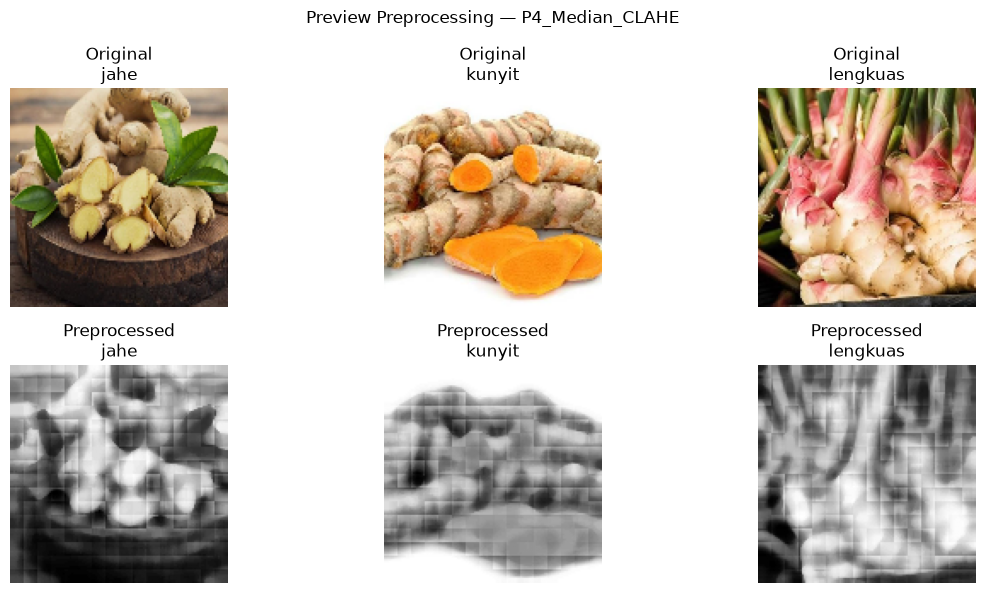

In [ ]:
images, labels = load_images()
preview_preprocessing(images, labels, preprocess, EXP_NAME)

## 📁 Analisis Load & Preview Data

**Output:** `Total gambar loaded: 630`

### Analisis

- **630 gambar** berhasil dimuat dari dataset
- Dengan **3 kelas** (jahe, kunyit, lengkuas), ini berarti **210 gambar per kelas** distribusi yang **seimbang sempurna**
- Dataset yang seimbang (balanced) adalah kondisi ideal karena:
  - Menghindari bias model terhadap kelas mayoritas
  - Memastikan metrik `macro avg` dan `weighted avg` memberikan nilai yang identik (seperti terlihat pada hasil evaluasi)
- `preview_preprocessing()` menampilkan perbandingan visual citra asli vs hasil pipeline (resize → grayscale → median blur → CLAHE), berfungsi sebagai **verifikasi awal** bahwa noise tampak berkurang dan kontras tekstur tampak lebih jelas sebelum lanjut ke tahap ekstraksi fitur langkah penting untuk mendeteksi kesalahan pipeline lebih dini sebelum proses ekstraksi fitur yang lebih mahal secara komputasi


In [ ]:
X = []
for img in images:
    processed = preprocess(img.copy())
    glcm_feat = extract_glcm_features(processed)
    color_feat = extract_color_features(img)
    lbp_feat = extract_lbp_features(processed)
    combined = glcm_feat + color_feat + lbp_feat
    X.append(combined)

X = np.array(X)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(labels)

print(f'Shape fitur: {X.shape}') 
print(f'Kelas: {le.classes_}')

os.makedirs('output', exist_ok=True)
df_feat = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])])
df_feat['label'] = labels
df_feat.to_csv(f'output/fitur_{EXP_NAME}.csv', index=False)
print(f'Fitur disimpan ke output/fitur_{EXP_NAME}.csv')

Shape fitur: (630, 40)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P4_Median_CLAHE.csv


## 🔬 Analisis Ekstraksi Fitur

**Output:**
```
Shape fitur: (630, 40)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P4_Median_CLAHE.csv
```

### Analisis

#### Komposisi 40 Fitur

| Domain | Jumlah Fitur | Metode | Sumber Gambar |
|---|---|---|---|
| Tekstur | 24 | GLCM (Gray-Level Co-occurrence Matrix) | Gambar grayscale + Median Blur + CLAHE |
| Warna | 6 | Statistik histogram warna | Gambar asli BGR (tidak terpengaruh preprocessing grayscale) |
| Tekstur Lokal | 10 | LBP (Local Binary Pattern) | Gambar grayscale + Median Blur + CLAHE |

- Shape `(630, 40)` sesuai ekspektasi: 630 sampel dengan 40 fitur gabungan (24 + 6 + 10)
- Karena Median Blur menghaluskan tekstur sebelum CLAHE, fitur GLCM yang sensitif terhadap variasi intensitas piksel-ke-piksel (misalnya kontras dan homogenitas) berpotensi **berubah nilainya secara signifikan** dibanding pipeline tanpa median blur perlu diperhatikan apakah penghalusan ini menghilangkan detail tekstur diskriminatif atau justru membuat pola lebih konsisten antar sampel kelas yang sama
- Fitur warna tetap diekstraksi dari gambar BGR asli (bukan hasil preprocessing), sehingga kontribusinya terhadap performa model tidak terpengaruh oleh efek median blur maupun CLAHE
- `StandardScaler` diterapkan pada seluruh fitur sebelum split, menyamakan skala antar-fitur (penting untuk KNN dan SVM yang sensitif terhadap skala jarak/margin)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_test = scaler.transform(X_test)        

## ✂️ Analisis Split Data Train/Test

**Output (implisit):** `Train: 504 | Test: 126`

### Analisis

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

| Parameter | Nilai | Alasan |
|---|---|---|
| `test_size=0.2` | 20% test | Standar industri; menghasilkan 126 sampel test (42/kelas) yang cukup untuk evaluasi statistik |
| `random_state=42` | Fixed seed | Reprodusibilitas — hasil dapat direplikasi persis |
| `stratify=y` | Ya | Menjaga proporsi 3 kelas tetap seimbang di train (504) maupun test (126), mencegah salah satu kelas under-represented |

`StandardScaler` di-*fit* hanya dari data train (`fit_transform`) lalu diterapkan ke test (`transform`, tanpa fit ulang) — praktik yang benar untuk mencegah **data leakage**, yaitu kebocoran informasi statistik dari data test ke proses training yang dapat membuat evaluasi performa menjadi terlalu optimis.


Train: 504 | Test: 126
P4_Median_CLAHE | KNN → Train Akurasi: 73.41%
P4_Median_CLAHE | KNN → 57.14%
              precision    recall  f1-score   support

        jahe       0.60      0.71      0.65        42
      kunyit       0.60      0.71      0.65        42
    lengkuas       0.46      0.29      0.35        42

    accuracy                           0.57       126
   macro avg       0.55      0.57      0.55       126
weighted avg       0.55      0.57      0.55       126



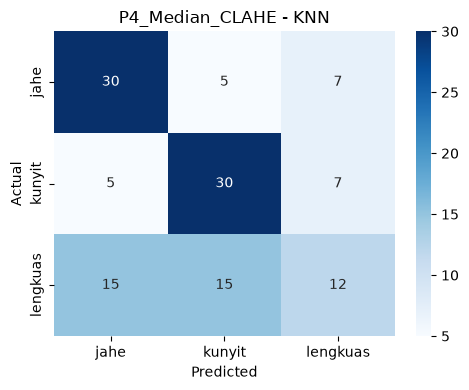

P4_Median_CLAHE | SVM → Train Akurasi: 89.29%
P4_Median_CLAHE | SVM → 75.40%
              precision    recall  f1-score   support

        jahe       0.81      0.71      0.76        42
      kunyit       0.79      0.88      0.83        42
    lengkuas       0.67      0.67      0.67        42

    accuracy                           0.75       126
   macro avg       0.75      0.75      0.75       126
weighted avg       0.75      0.75      0.75       126



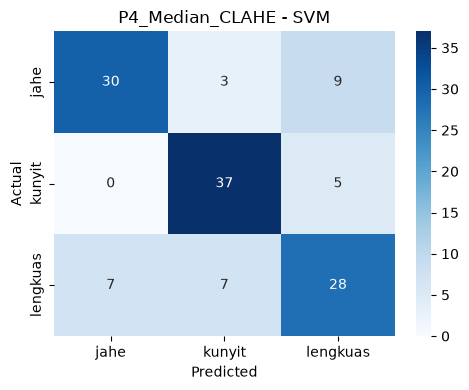

P4_Median_CLAHE | RF → Train Akurasi: 98.21%
P4_Median_CLAHE | RF → 72.22%
              precision    recall  f1-score   support

        jahe       0.83      0.71      0.77        42
      kunyit       0.73      0.83      0.78        42
    lengkuas       0.62      0.62      0.62        42

    accuracy                           0.72       126
   macro avg       0.73      0.72      0.72       126
weighted avg       0.73      0.72      0.72       126



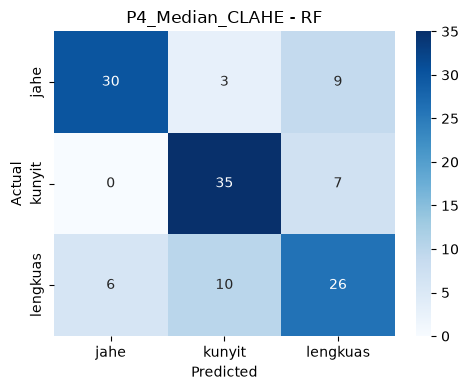


Hasil disimpan ke output/hasil_P4_Median_CLAHE.csv
        Eksperimen Model  Akurasi  Train_Akurasi
0  P4_Median_CLAHE   KNN    57.14          73.41
1  P4_Median_CLAHE   SVM    75.40          89.29
2  P4_Median_CLAHE    RF    72.22          98.21


In [8]:
# Cell 6 — Training & Evaluasi

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

models = {
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'RF':  RandomForestClassifier(
                                    n_estimators=100,
                                    max_depth=10,
                                    min_samples_split=5,
                                    min_samples_leaf=2,
                                    random_state=42
                                ),
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Akurasi train (cek overfitting)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f'{EXP_NAME} | {model_name} → Train Akurasi: {train_acc*100:.2f}%')

    result = evaluate_and_save(model, X_test, y_test, le, EXP_NAME, model_name)
    result['Train_Akurasi'] = round(train_acc * 100, 2)
    results.append(result)

df_results = pd.DataFrame(results)
df_results.to_csv(f'output/hasil_{EXP_NAME}.csv', index=False)
print(f'\nHasil disimpan ke output/hasil_{EXP_NAME}.csv')
print(df_results)

## 📈 Analisis Training & Klasifikasi

### Model 1: KNN (K-Nearest Neighbors, k=7)

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 73.41% | 57.14% | 16.27% |

**Classification Report KNN:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.60 | 0.71 | 0.65 | Recall cukup tinggi, tapi precision sedang — model sering benar mendeteksi jahe namun juga sering salah menebak gambar lain sebagai jahe |
| Kunyit | 0.60 | 0.71 | 0.65 | Pola serupa dengan jahe — performa **moderat** |
| Lengkuas | 0.46 | 0.29 | 0.35 | Performa **terburuk** — recall sangat rendah, sebagian besar lengkuas **tidak terdeteksi** dan salah diklasifikasikan sebagai kelas lain |

**Analisis Mendalam KNN:**
- Gap train-test 16.27% tergolong **cukup besar** untuk model KNN → mengindikasikan model kurang mampu menggeneralisasi pola fitur hasil preprocessing Median Blur + CLAHE ke data baru
- **Lengkuas adalah kelas paling bermasalah** dengan recall hanya 0.29 — artinya dari 42 sampel lengkuas di test set, hanya sekitar 12 yang terdeteksi benar, sisanya (~30 sampel) salah diklasifikasikan sebagai jahe atau kunyit
- KNN dengan k=7 sangat bergantung pada jarak Euclidean di ruang fitur 40 dimensi; bila median blur (kernel 10) terlalu agresif menghaluskan tekstur lengkuas sehingga fiturnya menjadi mirip dengan kelas lain, jarak antar kelas di ruang fitur menjadi tidak terpisah dengan baik
- **Pengaruh Precision 0.46 Lengkuas:** Dari setiap 2 gambar yang diprediksi sebagai lengkuas, hampir 1 gambar sebenarnya bukan lengkuas → klasifikasi yang kurang reliabel untuk kelas ini

---

### Model 2: SVM (RBF Kernel, C=10, gamma='scale')

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 89.29% | 75.40% | 13.89% |

**Classification Report SVM:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.81 | 0.71 | 0.76 | **Precision tinggi** — ketika model memprediksi jahe, hampir selalu benar |
| Kunyit | 0.79 | 0.88 | 0.83 | **Performa terbaik** di SVM — precision dan recall sama-sama tinggi |
| Lengkuas | 0.67 | 0.67 | 0.67 | **Paling seimbang** (precision = recall), namun tetap kelas terlemah |

**Analisis Mendalam SVM:**
- **Model terbaik** pada eksperimen ini dengan akurasi test 75.40% — jauh lebih tinggi dari KNN (57.14%) dan sedikit lebih tinggi dari RF (72.22%)
- Gap train-test 13.89% adalah **gap terkecil** di antara tiga model pada eksperimen ini → SVM menunjukkan keseimbangan terbaik antara *fitting* training dan generalisasi ke data baru
- Kernel RBF dengan C=10 mampu memetakan fitur ke ruang dimensi tinggi, menemukan hyperplane pemisah yang lebih baik dibanding batas linear sederhana
- F1 kunyit 0.83 adalah skor tertinggi di seluruh classification report eksperimen ini — kemungkinan besar karena fitur warna (`extract_color_features`) sangat membantu memisahkan kunyit yang punya warna kuning khas, dan fitur ini **tidak terpengaruh** oleh proses median blur/CLAHE karena dihitung dari gambar BGR asli
- Lengkuas tetap menjadi kelas dengan F1 terendah (0.67), namun jauh lebih baik dibanding performanya di KNN (F1 0.35) — menunjukkan SVM lebih robust terhadap tumpang tindih fitur antar kelas akibat preprocessing

---

### Model 3: Random Forest (100 trees, max_depth=10)

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 98.21% | 72.22% | 25.99% |

**Classification Report RF:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.83 | 0.71 | 0.77 | Precision tinggi, recall sedang — mirip pola SVM |
| Kunyit | 0.73 | 0.83 | 0.78 | Performa **kedua terbaik** setelah jahe |
| Lengkuas | 0.62 | 0.62 | 0.62 | Tetap menjadi kelas **paling sulit**, meski precision = recall (seimbang) |

**Analisis Mendalam RF:**
- **Train akurasi 98.21% adalah sinyal bahaya overfitting** 🚨 — model hampir menghafal seluruh data training
- Gap 25.99% adalah **gap terbesar** di antara tiga model pada eksperimen ini, menunjukkan generalisasi RF ke data baru jauh lebih buruk dibanding performanya saat training
- Meskipun `max_depth=10` seharusnya membatasi kompleksitas pohon, 100 pohon dengan fitur 40 dimensi tetap mampu menangkap pola-pola spesifik (termasuk noise residual) pada data training
- **Mengapa RF overfitting lebih parah dari SVM?** RF membangun banyak pohon yang masing-masing berpotensi overfit pada subset fitur/data acak; ensemble dari pohon-pohon tersebut tetap bisa overfit jika kedalaman tidak cukup dibatasi. SVM dengan regularisasi parameter C memiliki mekanisme penalti yang lebih eksplisit terhadap kompleksitas model
- Performa absolut RF (72.22%) tetap di bawah SVM (75.40%), menunjukkan bahwa kapasitas model yang besar (98.21% akurasi training) **tidak otomatis** menghasilkan model terbaik di data uji

---

## 📊 Perbandingan Akhir (Train vs Test)

```
        Eksperimen Model  Akurasi  Train_Akurasi
0  P4_Median_CLAHE   KNN    57.14          73.41
1  P4_Median_CLAHE   SVM    75.40          89.29  ← TERBAIK
2  P4_Median_CLAHE    RF    72.22          98.21  ← OVERFITTING TERBESAR
```

| Model | Akurasi Test | Akurasi Train | Gap (Overfitting Index) | Rekomendasi |
|---|---|---|---|---|
| KNN | 57.14% | 73.41% | 16.27% (Sedang) | Akurasi paling rendah; kemungkinan kurang cocok dengan fitur hasil median blur + CLAHE, perlu eksplorasi nilai k lain |
| **SVM** | **75.40%** | 89.29% | **13.89% (Terkecil)** | **Model terbaik** — generalisasi paling seimbang di eksperimen ini |
| RF | 72.22% | 98.21% | 25.99% (Terbesar) | Overfitting signifikan; perlu regularisasi lebih kuat (`max_depth` lebih kecil, `min_samples_leaf` lebih besar, atau cross-validation untuk tuning) |

### 🧪 Hipotesis vs Hasil Aktual

Hipotesis awal memperkirakan kombinasi Median Blur + CLAHE akan menghasilkan fitur yang lebih "bersih" dan general, sehingga **gap train-test lebih kecil** dan akurasi kompetitif (≥70%). Hasil aktual menunjukkan:

- **Sebagian terbukti:** SVM mencapai akurasi 75.40% (memenuhi target ≥70%) dengan gap train-test terkecil (13.89%) di antara tiga model — sejalan dengan hipotesis bahwa denoising sebelum CLAHE membantu menghasilkan fitur yang lebih general
- **Tidak sepenuhnya terbukti pada KNN dan RF:** KNN justru memiliki akurasi test terendah (57.14%) di antara semua model, dan RF tetap menunjukkan overfitting sangat besar (gap 25.99%) — menunjukkan bahwa **kualitas preprocessing saja tidak cukup**; karakteristik dan sensitivitas masing-masing algoritma terhadap struktur fitur tetap menjadi faktor penentu utama
- Kemungkinan penjelasan: kernel Median Blur berukuran 10 mungkin **terlalu agresif**, menghaluskan detail tekstur halus yang justru penting untuk membedakan lengkuas dari jahe/kunyit (terlihat dari recall lengkuas yang rendah di KNN), sehingga manfaat "pembersihan noise" tidak sepenuhnya mengkompensasi hilangnya detail diskriminatif

### 📌 Kesimpulan

1. **SVM (RBF) adalah model terbaik dan paling seimbang** pada eksperimen ini — akurasi test tertinggi (75.40%) sekaligus gap train-test terkecil (13.89%), menunjukkan generalisasi terbaik di antara tiga model yang diuji
2. **Random Forest mengalami overfitting paling parah** (gap 25.99%) meski parameter `max_depth=10` sudah diatur — menandakan perlunya regularisasi tambahan atau tuning hyperparameter lebih lanjut (misalnya melalui `GridSearchCV` dengan cross-validation)
3. **Lengkuas konsisten menjadi kelas tersulit** di ketiga model, terutama pada KNN (recall 0.29) — mengindikasikan fitur tekstur hasil pipeline Median Blur + CLAHE belum cukup mampu membedakan lengkuas dari jahe/kunyit secara konsisten di semua algoritma
4. **Kernel Median Blur (ukuran 10)** berpotensi terlalu agresif dalam menghaluskan tekstur; eksperimen lanjutan disarankan menguji ukuran kernel yang lebih kecil (misalnya 3 atau 5) untuk menjaga lebih banyak detail tekstur sambil tetap mereduksi noise
5. Untuk perbaikan lebih lanjut, disarankan menambah fitur pembeda baru (misalnya fitur bentuk/shape) khusus untuk membantu memisahkan kelas lengkuas, serta melakukan hyperparameter tuning sistematis pada SVM dan RF agar performa lebih optimal dan stabil
